In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Paths 
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
EXPORTS    = os.path.join(BASE_DIR, "data", "exports")
os.makedirs(VISUALS, exist_ok=True)
os.makedirs(EXPORTS, exist_ok=True)

# ── Database connection 
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1119, 20)


In [2]:
# ── Aggregate accident data by county ────────────────
# K-Means works at county level not individual records

county_stats = df.groupby('county').agg(
    total_accidents   = ('is_fatal', 'count'),
    total_fatalities  = ('is_fatal', 'sum'),
    total_victims     = ('num_victims', 'sum'),
    avg_victims       = ('num_victims', 'mean'),
    night_accidents   = ('time_of_day',
                         lambda x: (x=='Night').sum()),
    morning_accidents = ('time_of_day',
                         lambda x: (x=='Morning').sum()),
    evening_accidents = ('time_of_day',
                         lambda x: (x=='Evening').sum()),
).reset_index()

# ── Calculate derived metrics ─────────────────────────
county_stats['fatality_rate'] = (
    county_stats['total_fatalities'] /
    county_stats['total_accidents'] * 100
).round(2)

county_stats['night_rate'] = (
    county_stats['night_accidents'] /
    county_stats['total_accidents'] * 100
).round(2)

# ── Remove Unknown county ─────────────────────────────
county_stats = county_stats[
    county_stats['county'] != 'Unknown'
].reset_index(drop=True)

print("="*55)
print("COUNTY LEVEL STATISTICS")
print("="*55)
print(f"Total counties    : {len(county_stats)}")
print(f"\nTop 10 by accidents:")
print(county_stats.nlargest(10, 'total_accidents')[
    ['county','total_accidents',
     'total_fatalities','fatality_rate']
].to_string(index=False))

COUNTY LEVEL STATISTICS
Total counties    : 42

Top 10 by accidents:
  county  total_accidents  total_fatalities  fatality_rate
 NAIROBI              183                 4           2.19
  KIAMBU               99                 5           5.05
  NAKURU               76                 0           0.00
 MAKUENI               60                 1           1.67
MACHAKOS               50                 4           8.00
KAKAMEGA               40                 3           7.50
   NYERI               38                 2           5.26
  KILIFI               32                 0           0.00
 KAJIADO               31                 3           9.68
  KISUMU               30                 1           3.33


In [3]:
# ── Select features for K-Means ──────────────────────
cluster_features = [
    'total_accidents',
    'total_fatalities',
    'fatality_rate',
    'avg_victims',
    'night_rate'
]

X_cluster = county_stats[cluster_features].fillna(0)

# ── Scale the features ────────────────────────────────
# CRITICAL — K-Means uses distance calculations
# Features on different scales will dominate unfairly
# StandardScaler brings everything to same scale

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("="*55)
print("CLUSTERING FEATURES")
print("="*55)
print(f"Features used     : {cluster_features}")
print(f"Counties          : {len(X_cluster)}")
print()
print("Before scaling (sample):")
print(X_cluster.describe().round(2))

CLUSTERING FEATURES
Features used     : ['total_accidents', 'total_fatalities', 'fatality_rate', 'avg_victims', 'night_rate']
Counties          : 42

Before scaling (sample):
       total_accidents  total_fatalities  fatality_rate  avg_victims  \
count            42.00             42.00          42.00        42.00   
mean             26.07              0.93           4.86         1.18   
std              31.68              1.24           8.43         0.20   
min               1.00              0.00           0.00         1.00   
25%              10.25              0.00           0.00         1.06   
50%              16.50              1.00           2.76         1.13   
75%              28.50              1.00           6.67         1.24   
max             183.00              5.00          50.00         2.04   

       night_rate  
count       42.00  
mean        20.11  
std         14.43  
min          0.00  
25%         10.38  
50%         19.26  
75%         29.14  
max         50.0

In [4]:
# ── Test K from 2 to 8 ───────────────────────────────
inertia    = []
sil_scores = []
k_range    = range(2, 9)

for k in k_range:
    km = KMeans(
        n_clusters  = k,
        random_state= 42,
        n_init      = 10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X_scaled, km.labels_)
    )

print("="*55)
print("ELBOW METHOD RESULTS")
print("="*55)
print(f"{'K':>5} {'Inertia':>12} {'Silhouette':>12}")
print("-"*30)
for k, ine, sil in zip(k_range, inertia, sil_scores):
    print(f"{k:>5} {ine:>12.2f} {sil:>12.4f}")

ELBOW METHOD RESULTS
    K      Inertia   Silhouette
------------------------------
    2       154.96       0.3974
    3       119.86       0.3802
    4        93.83       0.2037
    5        72.94       0.2123
    6        58.15       0.2106
    7        47.95       0.2405
    8        42.93       0.2313


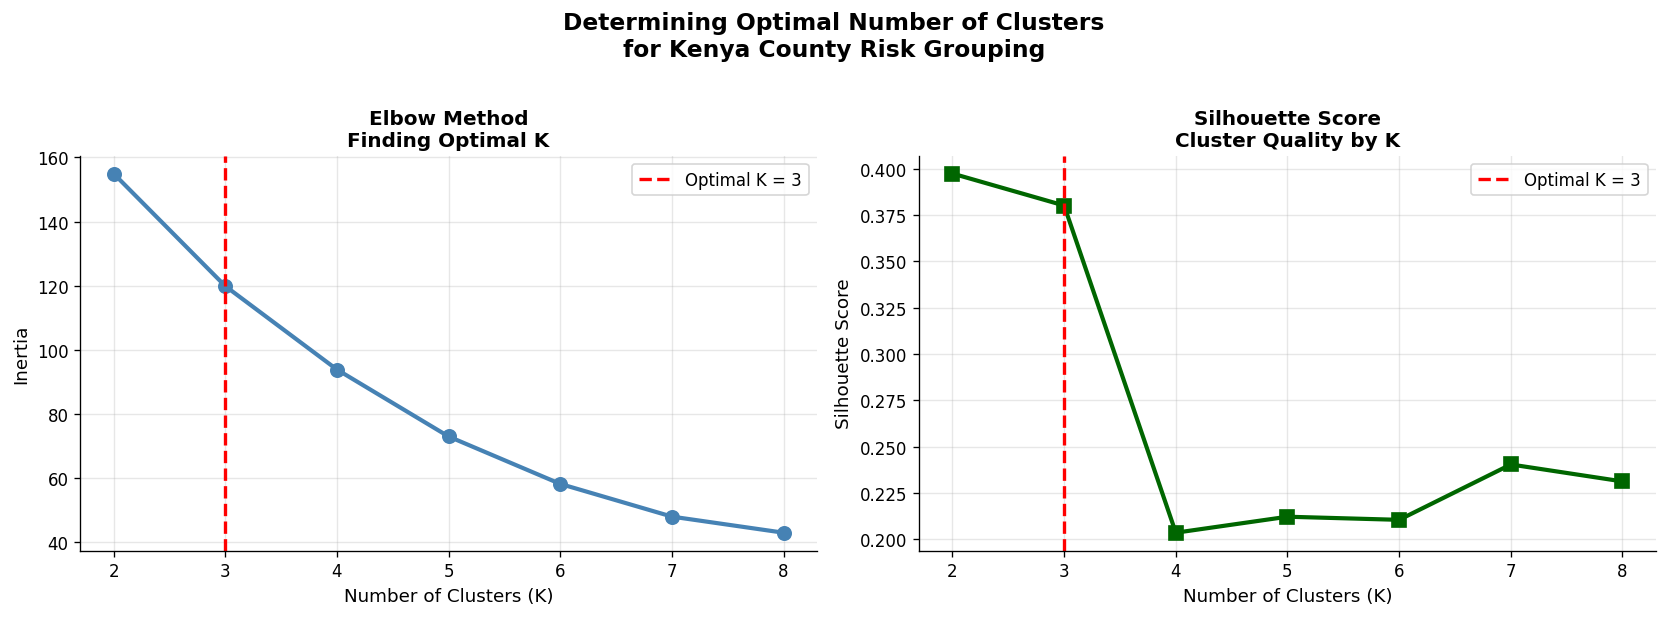

Chart saved


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Inertia (Elbow) plot ─────────────────────────────
ax1.plot(k_range, inertia,
         'o-', color='steelblue',
         linewidth=2.5, markersize=8)
ax1.axvline(x=3, color='red',
            linestyle='--', linewidth=2,
            label='Optimal K = 3')
ax1.set_title('Elbow Method\nFinding Optimal K',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(k_range))

# ── Silhouette Score plot ────────────────────────────
ax2.plot(k_range, sil_scores,
         's-', color='#006600',
         linewidth=2.5, markersize=8)
ax2.axvline(x=3, color='red',
            linestyle='--', linewidth=2,
            label='Optimal K = 3')
ax2.set_title('Silhouette Score\nCluster Quality by K',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(k_range))

plt.suptitle(
    'Determining Optimal Number of Clusters\n'
    'for Kenya County Risk Grouping',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'km_elbow_method.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

In [6]:
# ── Train with K=3 ───────────────────────────────────
kmeans = KMeans(
    n_clusters  = 3,
    random_state= 42,
    n_init      = 10,
    max_iter    = 300
)
kmeans.fit(X_scaled)

county_stats['cluster'] = kmeans.labels_

# ── Map cluster numbers to risk labels ───────────────
# K-Means assigns numbers 0,1,2 arbitrarily
# We sort by mean fatalities to assign correct labels

cluster_summary = county_stats.groupby('cluster').agg(
    mean_accidents   = ('total_accidents',  'mean'),
    mean_fatalities  = ('total_fatalities', 'mean'),
    mean_fatal_rate  = ('fatality_rate',    'mean'),
    county_count     = ('county',           'count')
).reset_index().sort_values('mean_fatalities')

# Assign labels based on fatality ranking
labels = ['Low Risk', 'Medium Risk', 'High Risk']
cluster_summary['risk_level'] = labels

risk_map = dict(zip(
    cluster_summary['cluster'],
    cluster_summary['risk_level']
))

county_stats['risk_level'] = (
    county_stats['cluster'].map(risk_map)
)

print("="*55)
print("CLUSTER SUMMARY")
print("="*55)
print(cluster_summary[[
    'risk_level', 'mean_accidents',
    'mean_fatalities', 'mean_fatal_rate',
    'county_count'
]].to_string(index=False))

print("\nCounty Risk Classifications:")
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    counties = county_stats[
        county_stats['risk_level'] == risk
    ]['county'].tolist()
    print(f"\n{risk} ({len(counties)} counties):")
    print("  " + ", ".join(sorted(counties)))

CLUSTER SUMMARY
 risk_level  mean_accidents  mean_fatalities  mean_fatal_rate  county_count
   Low Risk       18.676471         0.441176         3.084706            34
Medium Risk        2.000000         1.000000        50.000000             1
  High Risk       65.428571         3.285714         7.062857             7

County Risk Classifications:

High Risk (7 counties):
  KAJIADO, KAKAMEGA, KIAMBU, MACHAKOS, NAIROBI, NYERI, UASIN GISHU

Medium Risk (1 counties):
  ISIOLO

Low Risk (34 counties):
  BARINGO, BOMET, BUNGOMA, BUSIA, ELGEYO MARAKWET, EMBU, GARISSA, HOMA BAY, KERICHO, KILIFI, KIRINYAGA, KISII, KISUMU, KITUI, KWALE, LAIKIPIA, MAKUENI, MANDERA, MARSABIT, MERU, MIGORI, MOMBASA, MURANG'A, NAKURU, NANDI, NAROK, NYAMIRA, NYANDARUA, SIAYA, TAITA TAVETA, THARAKA NITHI, TRANS NZOIA, VIHIGA, WEST POKOT


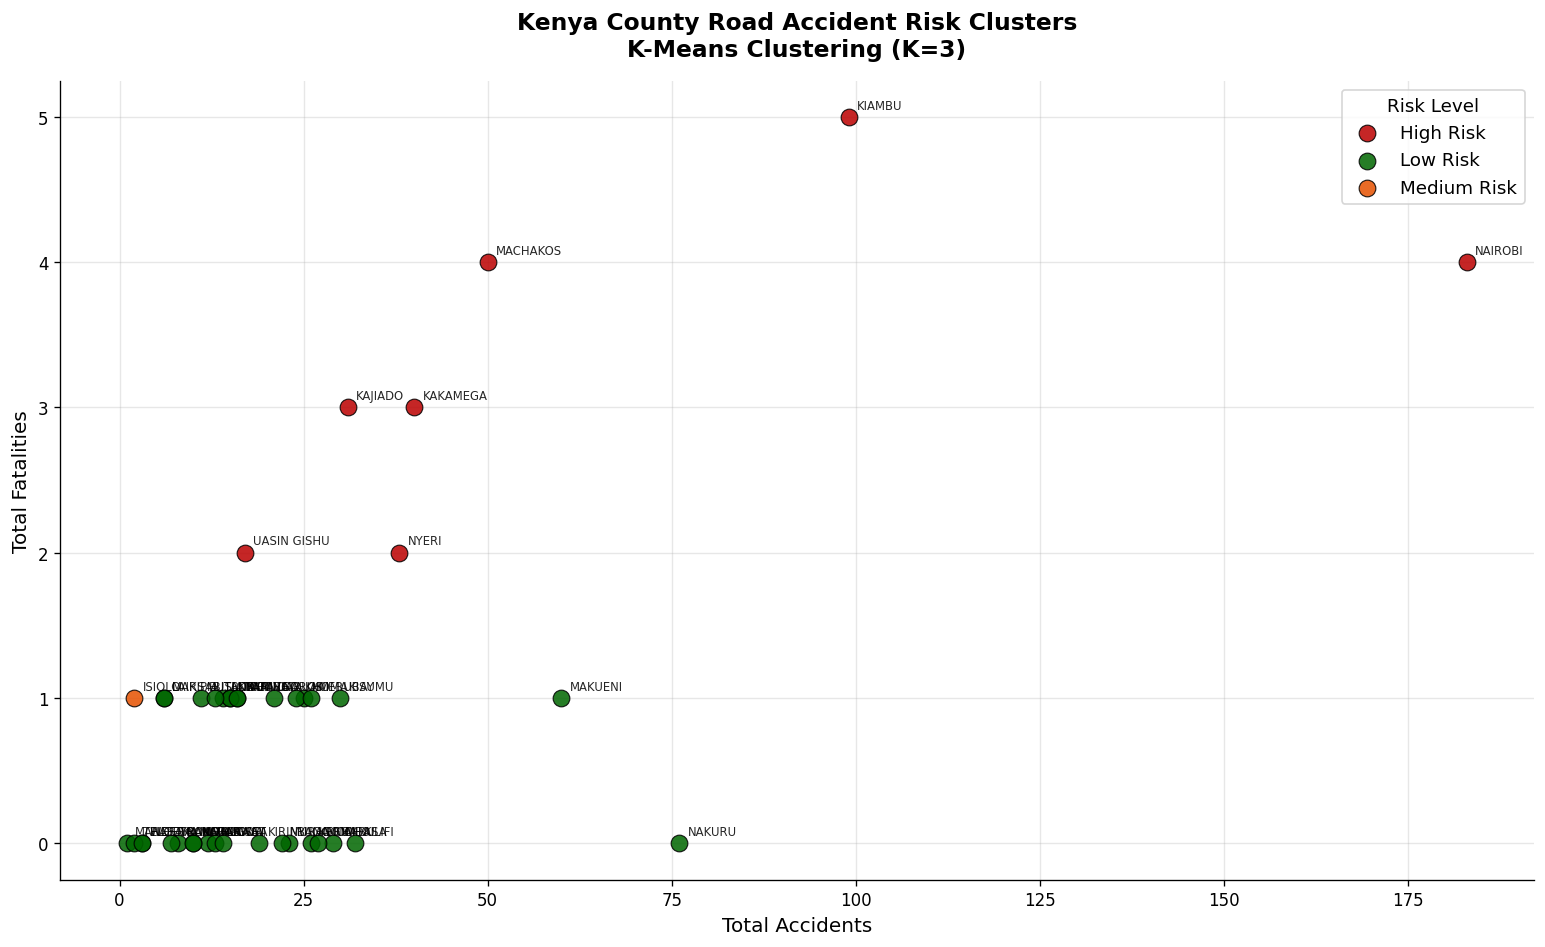

Chart saved


In [7]:
risk_colors = {
    'High Risk'  : '#BB0000',
    'Medium Risk': '#E65100',
    'Low Risk'   : '#006600'
}

fig, ax = plt.subplots(figsize=(13, 8))

for risk, group in county_stats.groupby('risk_level'):
    ax.scatter(
        group['total_accidents'],
        group['total_fatalities'],
        c     = risk_colors[risk],
        label = risk,
        s     = 100,
        edgecolors = 'black',
        linewidth  = 0.7,
        alpha      = 0.85,
        zorder     = 3
    )
    # Label each county
    for _, row in group.iterrows():
        ax.annotate(
            row['county'],
            (row['total_accidents'],
             row['total_fatalities']),
            fontsize   = 7,
            alpha      = 0.85,
            xytext     = (5, 5),
            textcoords = 'offset points'
        )

ax.set_title(
    'Kenya County Road Accident Risk Clusters\n'
    'K-Means Clustering (K=3)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Total Accidents', fontsize=12)
ax.set_ylabel('Total Fatalities', fontsize=12)
ax.legend(title='Risk Level', fontsize=11,
          title_fontsize=11)
ax.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'km_county_clusters.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

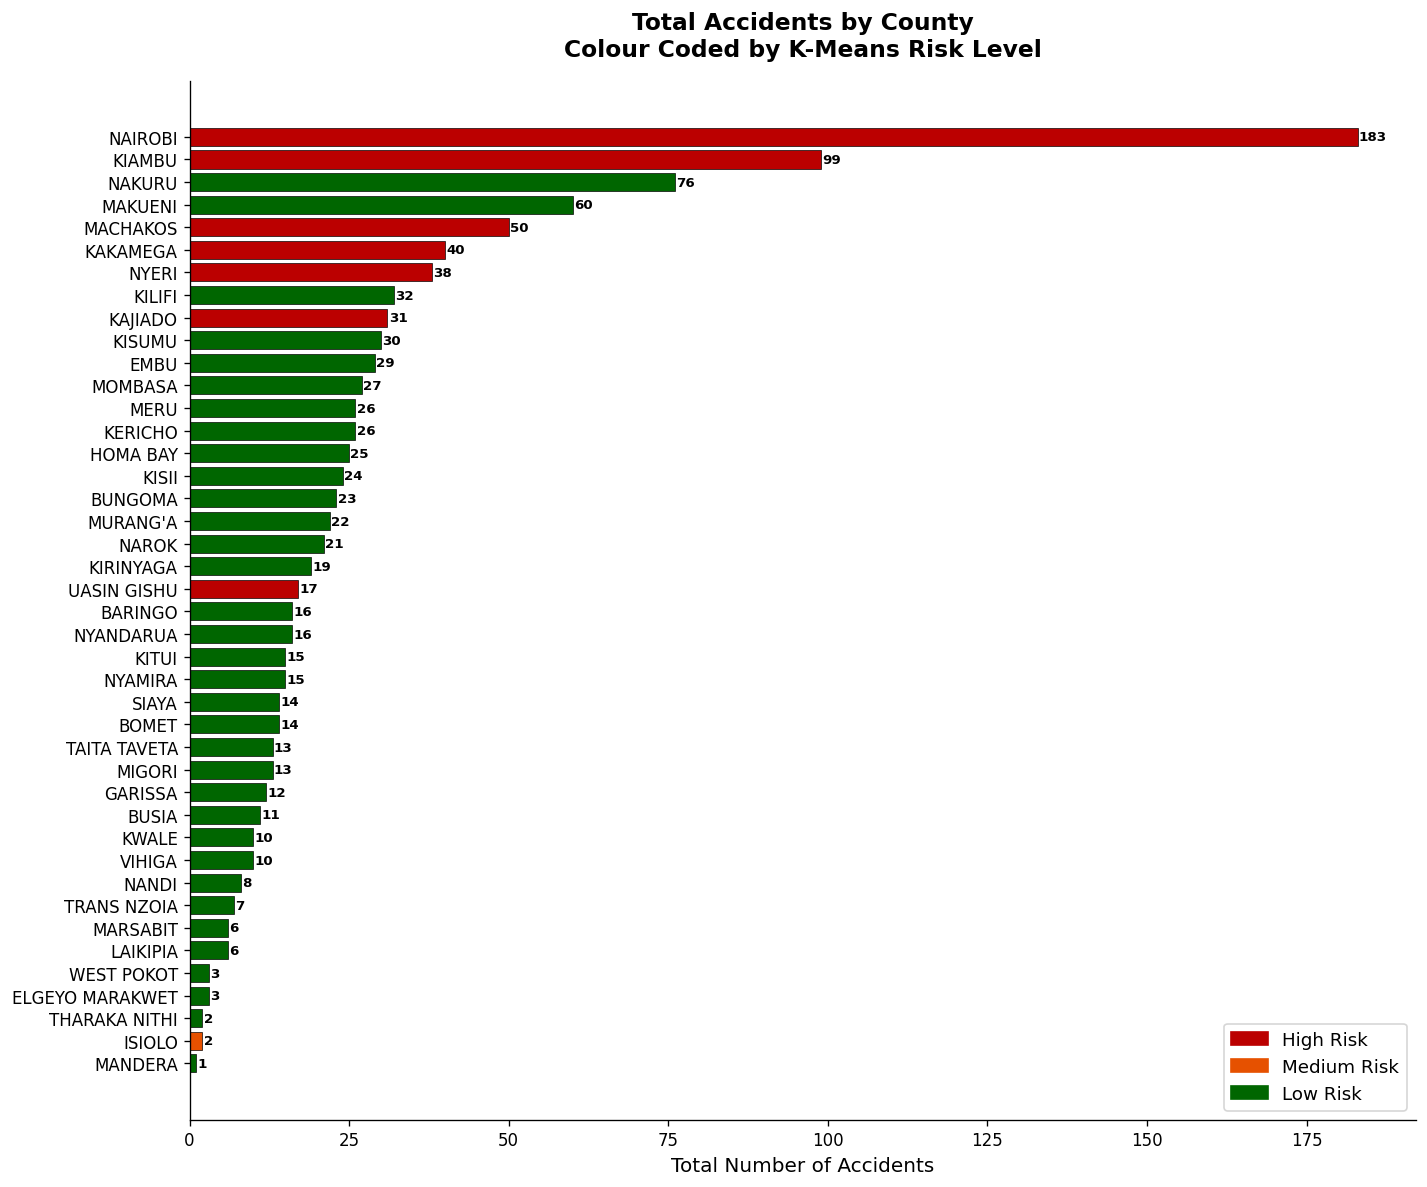

Chart saved


In [8]:
county_sorted = county_stats.sort_values(
    'total_accidents', ascending=True
)

bar_colors = [
    risk_colors[r] for r in county_sorted['risk_level']
]

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    county_sorted['county'],
    county_sorted['total_accidents'],
    color     = bar_colors,
    edgecolor = 'black',
    linewidth = 0.4
)

# Add value labels
for bar in bars:
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va='center', fontsize=8,
        fontweight='bold'
    )

ax.set_title(
    'Total Accidents by County\n'
    'Colour Coded by K-Means Risk Level',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Total Number of Accidents', fontsize=12)

legend_patches = [
    mpatches.Patch(color='#BB0000', label='High Risk'),
    mpatches.Patch(color='#E65100', label='Medium Risk'),
    mpatches.Patch(color='#006600', label='Low Risk'),
]
ax.legend(handles=legend_patches,
          loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'km_county_risk_bar.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

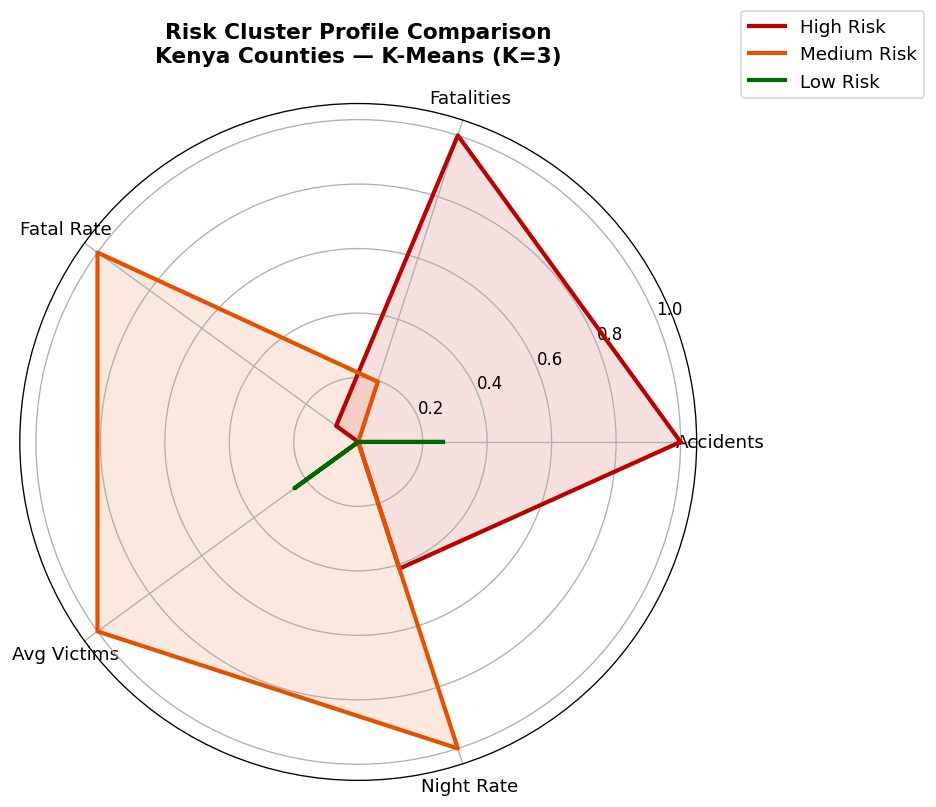

Chart saved


In [9]:
metrics       = ['Accidents', 'Fatalities',
                 'Fatal Rate', 'Avg Victims',
                 'Night Rate']
n_metrics     = len(metrics)

profile = county_stats.groupby('risk_level')[
    cluster_features
].mean()

# Normalize 0 to 1 for fair comparison
profile_norm = (profile - profile.min()) / (
    profile.max() - profile.min()
)

angles = np.linspace(
    0, 2 * np.pi, n_metrics, endpoint=False
).tolist()
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    if risk in profile_norm.index:
        values  = profile_norm.loc[risk].tolist()
        values += values[:1]
        ax.plot(
            angles, values,
            color     = risk_colors[risk],
            linewidth = 2.5,
            label     = risk
        )
        ax.fill(
            angles, values,
            color = risk_colors[risk],
            alpha = 0.12
        )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title(
    'Risk Cluster Profile Comparison\n'
    'Kenya Counties — K-Means (K=3)',
    fontsize=13, fontweight='bold', pad=25
)
ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.15),
    fontsize=11
)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'km_radar_chart.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

In [10]:
# ── Add coordinates for Power BI map ─────────────────
county_coordinates = {
    'NAIROBI'      : (-1.2921,  36.8219),
    'MOMBASA'      : (-4.0435,  39.6682),
    'NAKURU'       : (-0.3031,  36.0800),
    'KISUMU'       : (-0.1022,  34.7617),
    'KIAMBU'       : (-1.0313,  36.8318),
    'MACHAKOS'     : (-1.5177,  37.2634),
    'KILIFI'       : (-3.5107,  39.9093),
    'MERU'         : ( 0.0467,  37.6490),
    'KAKAMEGA'     : ( 0.2827,  34.7519),
    'UASIN GISHU'  : ( 0.5143,  35.2698),
    'MAKUENI'      : (-2.2558,  37.8938),
    'TAITA TAVETA' : (-3.3167,  38.4833),
    'BUNGOMA'      : ( 0.5635,  34.5606),
    'MIGORI'       : (-1.0634,  34.4734),
    'HOMA BAY'     : (-0.5267,  34.4571),
    'KISII'        : (-0.6817,  34.7667),
    'SIAYA'        : (-0.0617,  34.2422),
    'KIRINYAGA'    : (-0.5594,  37.3479),
    'NYERI'        : (-0.4167,  36.9500),
    "MURANG'A"     : (-0.7833,  37.0333),
    'KAJIADO'      : (-1.8500,  36.7833),
    'NAROK'        : (-1.0833,  35.8667),
    'KERICHO'      : (-0.3667,  35.2833),
    'BOMET'        : (-0.7833,  35.3500),
    'NANDI'        : ( 0.1833,  35.1167),
    'TRANS NZOIA'  : ( 1.0167,  35.0000),
    'BARINGO'      : ( 0.6500,  35.9833),
    'LAIKIPIA'     : ( 0.3500,  36.7833),
    'EMBU'         : (-0.5333,  37.4500),
    'KITUI'        : (-1.3667,  38.0167),
    'KWALE'        : (-4.1833,  39.4500),
    'THARAKA NITHI': ( 0.3000,  37.9833),
    'ISIOLO'       : ( 0.3500,  37.5833),
    'MARSABIT'     : ( 2.3333,  37.9833),
    'GARISSA'      : (-0.4532,  39.6461),
    'MANDERA'      : ( 3.9366,  41.8670),
    'WAJIR'        : ( 1.7471,  40.0573),
    'TURKANA'      : ( 3.1167,  35.5960),
    'WEST POKOT'   : ( 1.6167,  35.0833),
    'SAMBURU'      : ( 1.2167,  36.9833),
    'VIHIGA'       : ( 0.0833,  34.7167),
    'BUSIA'        : ( 0.4608,  34.1117),
    'NYAMIRA'      : (-0.5667,  34.9333),
    'NYANDARUA'    : (-0.1833,  36.5167),
    'LAMU'         : (-2.2686,  40.9020),
    'TANA RIVER'   : (-1.5000,  39.9167),
    'ELGEYO MARAKWET': ( 0.5000, 35.4833),
}

county_stats['latitude'] = county_stats['county'].map(
    lambda x: county_coordinates.get(x, (None, None))[0]
)
county_stats['longitude'] = county_stats['county'].map(
    lambda x: county_coordinates.get(x, (None, None))[1]
)

# ── Select columns for Power BI export ───────────────
powerbi_export = county_stats[[
    'county', 'total_accidents', 'total_fatalities',
    'fatality_rate', 'avg_victims', 'night_rate',
    'risk_level', 'latitude', 'longitude'
]].copy()

# ── Save to exports folder ───────────────────────────
export_path = os.path.join(
    EXPORTS, 'county_risk_powerbi.csv'
)
powerbi_export.to_csv(export_path, index=False)

print("="*55)
print("POWER BI EXPORT COMPLETE")
print("="*55)
print(f"File saved to: {export_path}")
print(f"Total counties: {len(powerbi_export)}")
print()
print("Risk level distribution:")
print(powerbi_export['risk_level'].value_counts())
print()
print("High Risk Counties:")
high_risk = powerbi_export[
    powerbi_export['risk_level'] == 'High Risk'
][['county','total_accidents','fatality_rate']]
print(high_risk.to_string(index=False))

POWER BI EXPORT COMPLETE
File saved to: C:\Users\Administrator\Desktop\kenya_road_safety_project\data\exports\county_risk_powerbi.csv
Total counties: 42

Risk level distribution:
risk_level
Low Risk       34
High Risk       7
Medium Risk     1
Name: count, dtype: int64

High Risk Counties:
     county  total_accidents  fatality_rate
    KAJIADO               31           9.68
   KAKAMEGA               40           7.50
     KIAMBU               99           5.05
   MACHAKOS               50           8.00
    NAIROBI              183           2.19
      NYERI               38           5.26
UASIN GISHU               17          11.76


In [11]:
# ── Save county risk data to PostgreSQL ──────────────
county_stats.to_sql(
    'county_risk_clusters',
    engine,
    if_exists = 'replace',
    index     = False,
    chunksize = 100
)

# Verify
with engine.connect() as conn:
    result = conn.execute(
        text("SELECT COUNT(*) FROM county_risk_clusters")
    )
    print(f"Records in PostgreSQL: {result.fetchone()[0]}")

print("County risk data saved to PostgreSQL")

Records in PostgreSQL: 42
County risk data saved to PostgreSQL


In [13]:
sil = silhouette_score(X_scaled, kmeans.labels_)

print("="*55)
print("NOTEBOOK 8 COMPLETE — K-MEANS CLUSTERING")
print("="*55)
print(f"\nAlgorithm     : K-Means Clustering")
print(f"K value       : 3 (High/Medium/Low Risk)")
print(f"Counties      : {len(county_stats)}")
print()
print("Cluster Quality:")
print(f"  Inertia          : {kmeans.inertia_:.2f}")
print(f"  Silhouette Score : {sil:.4f}")
print()
print("Risk Distribution:")
for risk in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = (county_stats['risk_level']==risk).sum()
    counties = county_stats[
        county_stats['risk_level']==risk
    ]['county'].tolist()
    print(f"  {risk:<15}: {count} counties")
print()
print("Charts saved:")
print("  km_elbow_method.png")
print("  km_county_clusters.png")
print("  km_county_risk_bar.png")
print("  km_radar_chart.png")
print()
print("Exports saved:")
print("  data/exports/county_risk_powerbi.csv")
print("  PostgreSQL: county_risk_clusters table")
print()
print("="*55)
print("ALL 8 NOTEBOOKS COMPLETE")
print("="*55)

NOTEBOOK 8 COMPLETE — K-MEANS CLUSTERING

Algorithm     : K-Means Clustering
K value       : 3 (High/Medium/Low Risk)
Counties      : 42

Cluster Quality:
  Inertia          : 119.86
  Silhouette Score : 0.3802

Risk Distribution:
  High Risk      : 7 counties
  Medium Risk    : 1 counties
  Low Risk       : 34 counties

Charts saved:
  km_elbow_method.png
  km_county_clusters.png
  km_county_risk_bar.png
  km_radar_chart.png

Exports saved:
  data/exports/county_risk_powerbi.csv
  PostgreSQL: county_risk_clusters table

ALL 8 NOTEBOOKS COMPLETE
